In [1]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score, accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from scipy.stats import randint
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
import warnings
warnings.filterwarnings('ignore')


In [4]:
car_data = pd.read_csv("cleaned_car_data.csv")
car_data.head()
car_data.info()
car_data.describe()
car_data.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4005 non-null   str  
 1   model         4005 non-null   str  
 2   model_year    4005 non-null   int64
 3   milage        4005 non-null   int64
 4   fuel_type     4005 non-null   str  
 5   engine        4005 non-null   str  
 6   transmission  4005 non-null   str  
 7   ext_col       4005 non-null   str  
 8   int_col       4005 non-null   str  
 9   accident      4005 non-null   str  
 10  clean_title   4005 non-null   bool 
 11  price         4005 non-null   int64
dtypes: bool(1), int64(3), str(8)
memory usage: 348.2 KB


brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [5]:
import sys

print(f"Python Path: {sys.executable}")


Python Path: c:\Users\hp\OneDrive - Cloudelligent LLC\AWS-AI-Internship\Week 5\.venv\Scripts\python.exe


In [6]:
car_data

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,At least 1 accident or damage reported,True,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,True,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,False,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,None reported,True,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,Glacier White Metallic,Black,None reported,False,34999
...,...,...,...,...,...,...,...,...,...,...,...,...
4000,Bentley,Continental GT Speed,2023,714,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,Automatic,C / C,Hotspur,None reported,True,349950
4001,Audi,S4 3.0T Premium Plus,2022,10900,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Other,Black,Black,None reported,True,53900
4002,Porsche,Taycan,2022,2116,Gasoline,Electric,Automatic,Black,Black,None reported,False,90998
4003,Ford,F-150 Raptor,2020,33000,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Automatic,Blue,Black,None reported,True,62999


KDE Plots for Year, Mileage and Car price.

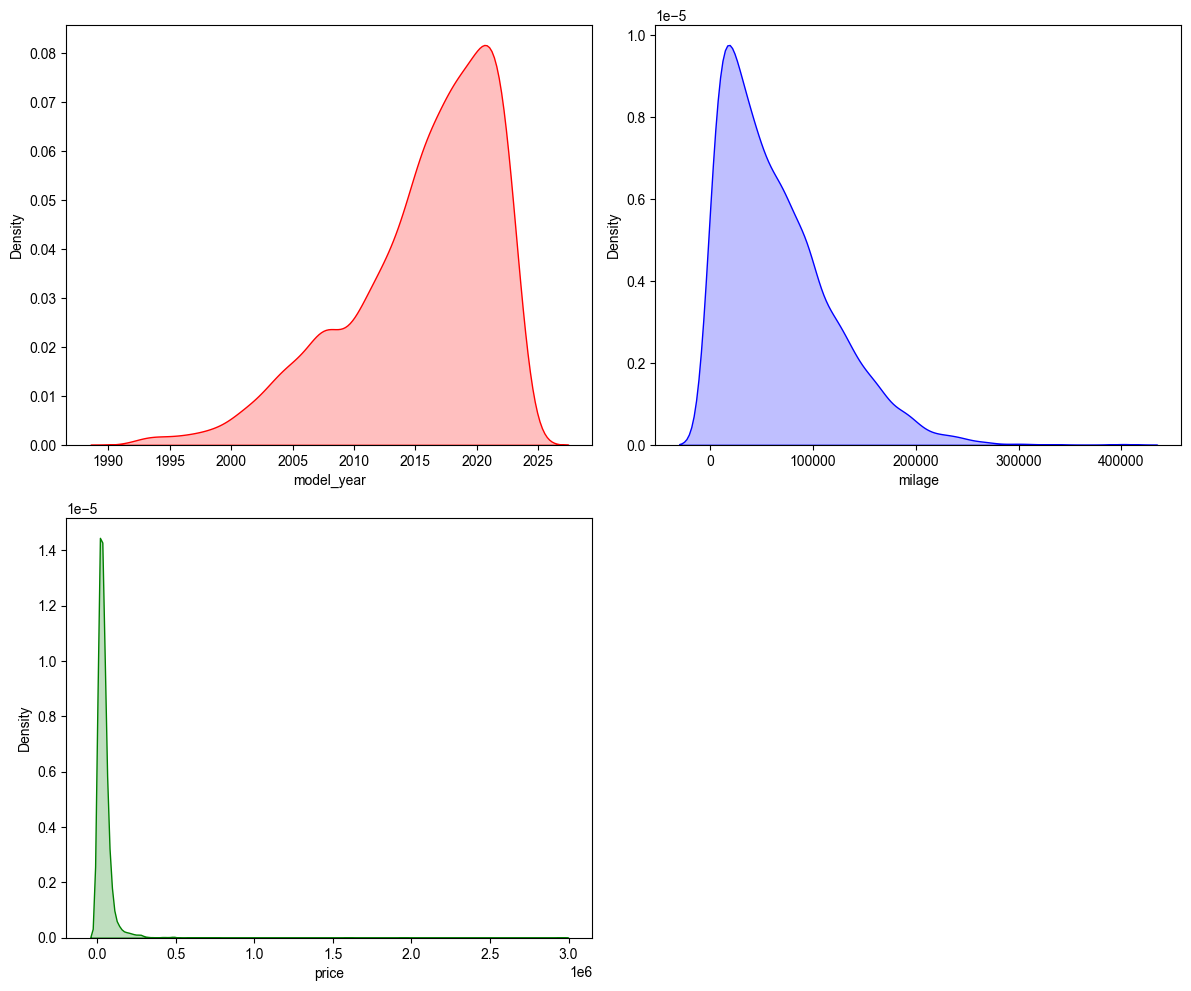

In [7]:
n_rows= 2
numeric_columns= car_data.select_dtypes(include=int).columns.to_list()
n_columns= int(np.ceil(len(numeric_columns)/n_rows))
colors= ['red', 'blue', 'green']

plt.figure(figsize=(12,10))
for idx, column in enumerate(car_data[numeric_columns],1):
    plt.subplot(n_rows, n_columns, idx)
    #sns.histplot(data=Car_data, x=column, bins=50, kde=True)
    sns.kdeplot(data=car_data, x= column, fill=colors[idx-1], color=colors[idx-1])
sns.set_theme('paper')
plt.tight_layout()

<Axes: xlabel='price', ylabel='Density'>

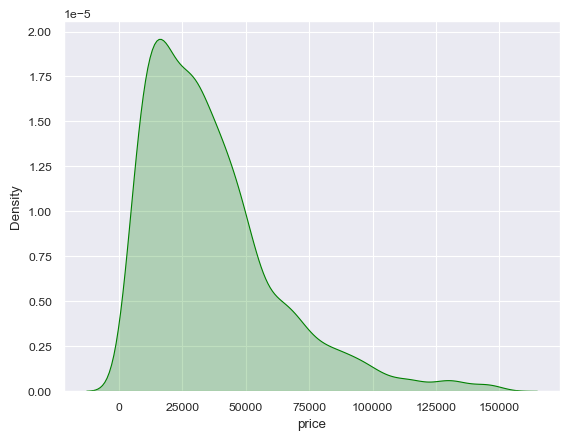

In [8]:
# Create a new dataframe with only 'normal' priced cars
normal_cars = car_data[car_data['price'] < 150000]

# Now plot using this filtered data
sns.kdeplot(data=normal_cars, x='price', fill=True, color='green')

In [9]:
car_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4005 non-null   str  
 1   model         4005 non-null   str  
 2   model_year    4005 non-null   int64
 3   milage        4005 non-null   int64
 4   fuel_type     4005 non-null   str  
 5   engine        4005 non-null   str  
 6   transmission  4005 non-null   str  
 7   ext_col       4005 non-null   str  
 8   int_col       4005 non-null   str  
 9   accident      4005 non-null   str  
 10  clean_title   4005 non-null   bool 
 11  price         4005 non-null   int64
dtypes: bool(1), int64(3), str(8)
memory usage: 348.2 KB


Extracting horse power feature from Engine

Feature Enginnering

In [10]:
car_data['horse_power']=car_data['engine'].str.extract(r'(\d+(?:\.\d+)?)\s*HP').astype(float)

Creating a new column Engine Capacity

In [11]:
car_data['engine_capacity']=car_data['engine'].str.extract(r'(\d+(?:\.\d)?)\s*L').astype(float)

Creating a new column cylinders

In [12]:
car_data['cylinder_number']=car_data['engine'].str.extract(r'(\d+(?:\.\d)?)\s*Cylinder')
car_data['cylinder_number']= car_data['cylinder_number'].replace(np.nan, 0)
car_data['cylinder_number']=car_data['cylinder_number'].astype(int)

Converting model year into Age

In [13]:
car_data['age']=2025-car_data['model_year']

Dropping Features Engine and model_year

In [14]:
car_data = car_data.drop(columns = ['model_year','engine'])

Check outliers in new features

In [15]:
car_data[['horse_power', 'engine_capacity', 'cylinder_number']].describe()


,horse_power,engine_capacity,cylinder_number
count,3201.000000,3790.000000,4005.000000
mean,332.206498,3.805726,4.787765
std,122.258492,3.102259,3.032113
min,70.000000,1.000000,0.000000
25%,248.000000,2.500000,4.000000
50%,310.000000,3.500000,6.000000
75%,400.000000,4.700000,8.000000
max,1020.000000,75.000000,12.000000


We can see from the above table the engine capacity value is 70 which is not normal. Normal engine capacity ranges from 660cc to 8.4 litres. It is possible that anomaly occured due to an outlier. To confirm outliers we use the following command

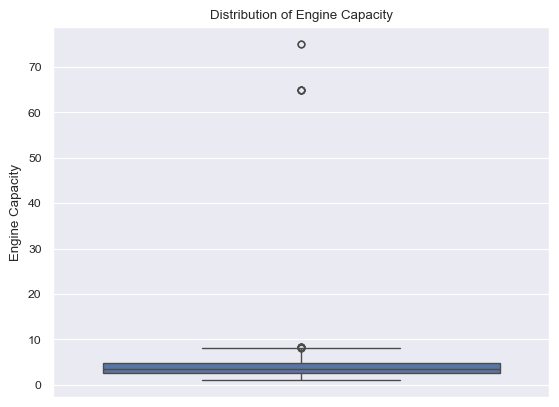

In [16]:
sns.boxplot(data=car_data, y='engine_capacity')
plt.title('Distribution of Engine Capacity')
plt.ylabel('Engine Capacity')
plt.show()

We can see that there are only 2 outliers so can just ignore the values greater than 10.

In [17]:
car_data.loc[car_data['engine_capacity'] > 10, 'engine_capacity'] = car_data.loc[car_data['engine_capacity'] > 10, 'engine_capacity'] / 10

Creating the copy of the dataset at hand

In [18]:
car_data_copy = car_data.copy()

In [19]:
car_data_copy2 = car_data.copy()

In [20]:
Q1 = car_data_copy['price'].quantile(0.25)
Q3 = car_data_copy['price'].quantile(0.75)
IQR = Q3 - Q1

# Define the 'Upper Whisker'
upper_limit = Q3 + 1.5 * IQR

# Remove anything above the limit
car_data_copy = car_data_copy[car_data_copy['price'] <= upper_limit]

In [21]:
car_data_copy

,brand,model,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,horse_power,engine_capacity,cylinder_number,age
0,Ford,Utility Police Interceptor Base,51000,E85 Flex Fuel,Automatic,Black,Black,At least 1 accident or damage reported,True,10300,300.0,3.7,6,12
1,Hyundai,Palisade SEL,34742,Gasoline,Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,True,38005,NaN,3.8,0,4
2,Lexus,RX 350 RX 350,22372,Gasoline,Automatic,Blue,Black,None reported,False,54598,NaN,3.5,0,3
3,INFINITI,Q50 Hybrid Sport,88900,Hybrid,Automatic,Black,Black,None reported,True,15500,354.0,3.5,6,10
4,Audi,Q3 45 S line Premium Plus,9835,Gasoline,Automatic,Glacier White Metallic,Black,None reported,False,34999,NaN,2.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,Mercedes-Benz,E-Class E 300 4MATIC,53705,Gasoline,Automatic,Black,Black,At least 1 accident or damage reported,True,25900,241.0,2.0,4,7
4001,Audi,S4 3.0T Premium Plus,10900,Gasoline,Other,Black,Black,None reported,True,53900,349.0,3.0,6,3
4002,Porsche,Taycan,2116,Gasoline,Automatic,Black,Black,None reported,False,90998,NaN,NaN,0,3
4003,Ford,F-150 Raptor,33000,Gasoline,Automatic,Blue,Black,None reported,True,62999,450.0,3.5,6,5


We can drop those features in the dataset which offer no value in modelling. Some features are redundant such as brand name, interior color and exterior color

In [22]:
car_data_copy = car_data_copy.drop(columns=['model', 'int_col', 'ext_col', 'brand'])

In [23]:
car_data_copy

,milage,fuel_type,transmission,accident,clean_title,price,horse_power,engine_capacity,cylinder_number,age
0,51000,E85 Flex Fuel,Automatic,At least 1 accident or damage reported,True,10300,300.0,3.7,6,12
1,34742,Gasoline,Automatic,At least 1 accident or damage reported,True,38005,NaN,3.8,0,4
2,22372,Gasoline,Automatic,None reported,False,54598,NaN,3.5,0,3
3,88900,Hybrid,Automatic,None reported,True,15500,354.0,3.5,6,10
4,9835,Gasoline,Automatic,None reported,False,34999,NaN,2.0,0,4
...,...,...,...,...,...,...,...,...,...,...
3999,53705,Gasoline,Automatic,At least 1 accident or damage reported,True,25900,241.0,2.0,4,7
4001,10900,Gasoline,Other,None reported,True,53900,349.0,3.0,6,3
4002,2116,Gasoline,Automatic,None reported,False,90998,NaN,NaN,0,3
4003,33000,Gasoline,Automatic,None reported,True,62999,450.0,3.5,6,5


Splitting the features and target label

In [24]:
x = car_data_copy.drop(columns=['price'])
y = car_data_copy['price']

Splitting the dataset into training and testing set

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Now we need to take the numerical features and put the features in the same scale suc as mileage and year. As large value of mileage may trick the AI to think that mileage is more important than model_year or price.

In [26]:
numeric_features= x.select_dtypes(include=[int, float]).columns.to_list()
num_pipeline= Pipeline([
    ('imputer', IterativeImputer()),
    ('scaler', StandardScaler())
])


Now we need to encode string features to numerical values using One host encoding

In [27]:
catecategorical_features= x.select_dtypes(include=['object']).columns.to_list()
cat_pipeline= Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Merging the pipelines. Numerical and categorical features are separated into different pipelines num_pipline and cat_piplne respectively. 

In [28]:
preprocessor= ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, catecategorical_features)
])

Using Random Forest for training

In [29]:
rf_model= RandomForestRegressor(random_state=42, n_estimators=300, max_depth=7, min_samples_split=8, min_samples_leaf=4, max_features='sqrt')
rf_pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)
])
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [30]:
rf_y_pred= rf_pipeline.predict(X_test)

#Evaluating the model:

#For testing Dataset
mae= mean_absolute_error(y_test, rf_y_pred)
R2=r2_score(y_test, rf_y_pred)
mse= mean_squared_error(y_test, rf_y_pred)
print("For Random Forest Algorithm (Test Data):")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {R2:.4f}")
print(f"MAE Score: {mae:.4f}")


#For training dataset
rf_y_pred1=rf_pipeline.predict(X_train)
mae= mean_absolute_error(y_train, rf_y_pred1)
R2=r2_score(y_train, rf_y_pred1)
mse= mean_squared_error(y_train, rf_y_pred1)
print("\n\nFor Random Forest Algorithm: (Train Data)")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {R2:.4f}")
print(f"MAE Score: {mae:.4f}")

For Random Forest Algorithm (Test Data):
MSE: 118093693.0192
R2 Score: 0.7306
MAE Score: 7751.3066


For Random Forest Algorithm: (Train Data)
MSE: 92802043.0611
R2 Score: 0.7987
MAE Score: 6853.0188


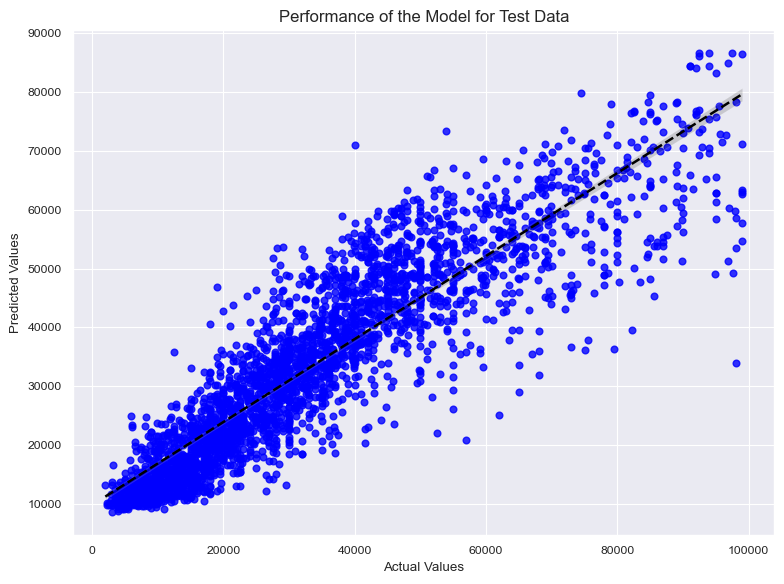

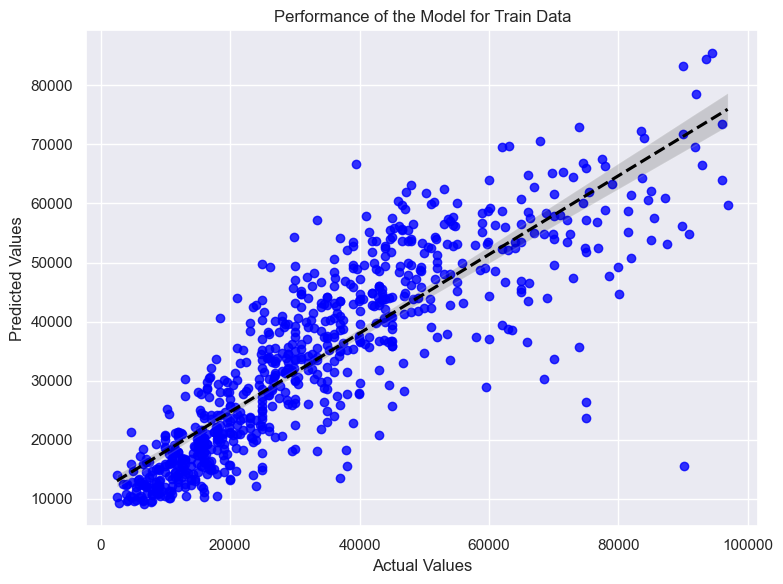

In [31]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_train, y=rf_y_pred1, color='blue', line_kws={'color':'black', 'linestyle':'--'})
sns.set_style('whitegrid')
sns.set_theme('notebook')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Performance of the Model for Test Data')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=rf_y_pred, color='blue', line_kws={'color':'black', 'linestyle':'--'})
sns.set_style('whitegrid')
sns.set_theme('notebook')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Performance of the Model for Train Data')
plt.tight_layout()
plt.show()

Now we need to visualise which fatures are the most important for the random Forest algorithm we used for training on the data.

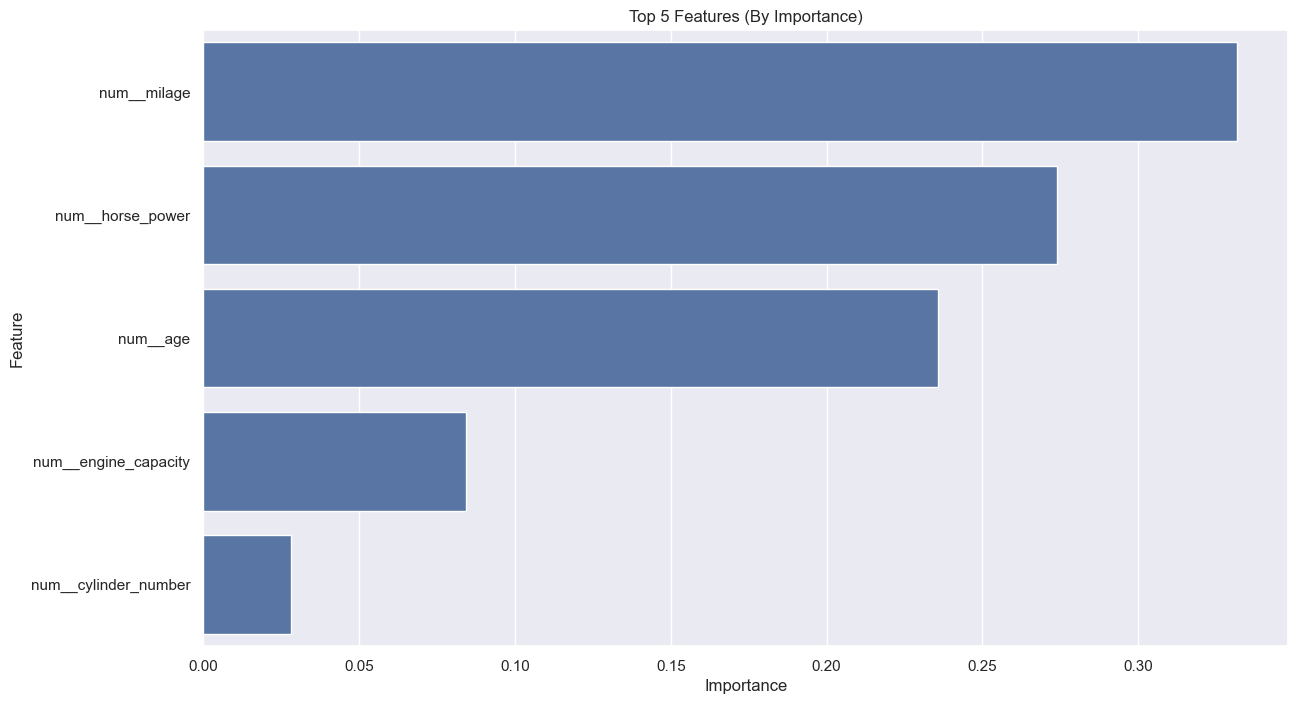

In [32]:
ct = rf_pipeline.named_steps['preprocessor']
feature_names = ct.get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

important_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(14,8))
sns.barplot(data=important_features.head(5),
            x='Importance',
            y='Feature')
plt.title('Top 5 Features (By Importance)')
plt.show()

Linear Regression Model

In [33]:
lr_model= LinearRegression()

lr_pipeline= Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr_model)
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Results of Linear Regression Model

In [34]:
lr_y_pred= lr_pipeline.predict(X_test)
mse = mean_squared_error(y_test, lr_y_pred)
r2 = r2_score(y_test, lr_y_pred)
mae_final = mean_absolute_error(y_test, lr_y_pred)
print("For Liner Regression Model:")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAE Score: {mae_final:.4f}")

For Liner Regression Model:
MSE: 149993371.9363
R2 Score: 0.6578
MAE Score: 9047.0085


Visual Performance of the model

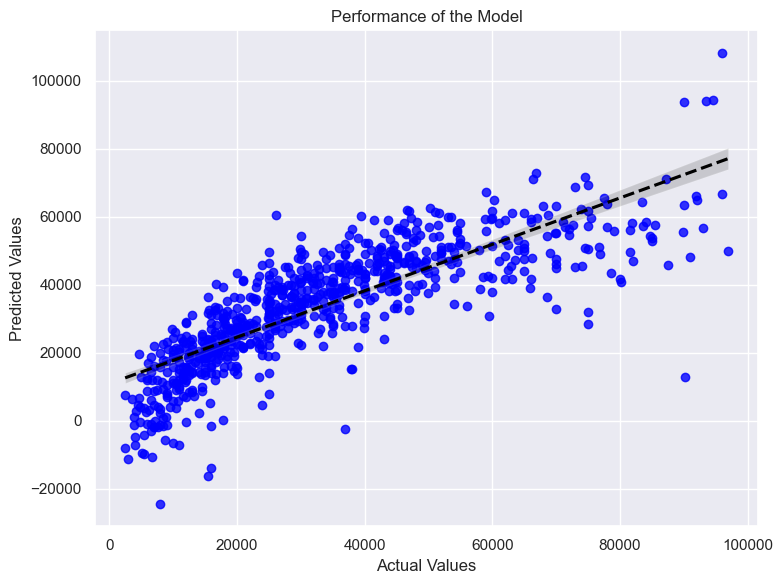

In [35]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=lr_y_pred, color='blue', line_kws={'color':'black', 'linestyle':'--'})
sns.set_style('whitegrid')
sns.set_theme('notebook')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Performance of the Model')
plt.tight_layout()
plt.show()

Implementing XGBoost to test the accuracy of the model on the cars dataset

In [90]:
from xgboost import XGBRegressor


# Initialize the XGBoost model with hyperparameters to prevent overfitting
xgb_model = XGBRegressor(
    n_estimators=450,
    max_depth=4,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Create the master pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# Train the model
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Evaluating XGBoost model

In [91]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = xgb_pipeline.predict(X_test)

print(f"XGBoost R2 Score: {r2_score(y_test, y_pred)}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, y_pred)}")

XGBoost R2 Score: 0.802221417427063
XGBoost MAE: 6351.47998046875


In [92]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Get predictions for both sets
train_preds = xgb_pipeline.predict(X_train)
test_preds = xgb_pipeline.predict(X_test)

# 2. Calculate and Print Metrics
print("--- XGBOOST PERFORMANCE ---")
print(f"Train R2 Score: {r2_score(y_train, train_preds):.4f}")
print(f"Test R2 Score:  {r2_score(y_test, test_preds):.4f}")
print("-" * 27)
print(f"Train MAE: ${mean_absolute_error(y_train, train_preds):,.2f}")
print(f"Test MAE:  ${mean_absolute_error(y_test, test_preds):,.2f}")

--- XGBOOST PERFORMANCE ---
Train R2 Score: 0.9425
Test R2 Score:  0.8022
---------------------------
Train MAE: $3,733.38
Test MAE:  $6,351.48


using k fold cross validation to find out wy the model is overfitting

In [63]:
from sklearn.model_selection import cross_val_score

# We use the pipeline so the data is scaled/encoded correctly in every fold
# cv=5 means 5-fold cross-validation
scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='r2')

print(f"R2 Scores for each fold: {scores}")
print(f"Average R2 Score: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

R2 Scores for each fold: [0.80464292 0.82485092 0.80776834 0.81010485 0.84323335]
Average R2 Score: 0.8181
Standard Deviation: 0.0143


In [86]:
from sklearn.model_selection import GridSearchCV

# 1. Define a focused grid based on your current optimal settings
param_grid = {
    'model__min_child_weight': [1, 5, 10],   # Higher = more conservative
    'model__gamma': [0, 1, 5],               # Higher = more pruning
    'model__learning_rate': [0.05, 0.1],     # Testing a slower rate for better convergence
    'model__max_depth': [4]                  # Keeping your proven depth of 4
}

# 2. Setup GridSearch with your existing pipeline
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,                                    # 5-fold CV as per your screenshot
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 3. Fit the search
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Improved Cross-Val R2: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_child_weight': 1}
Improved Cross-Val R2: 0.8200


PLot the results obtained from XGBoost

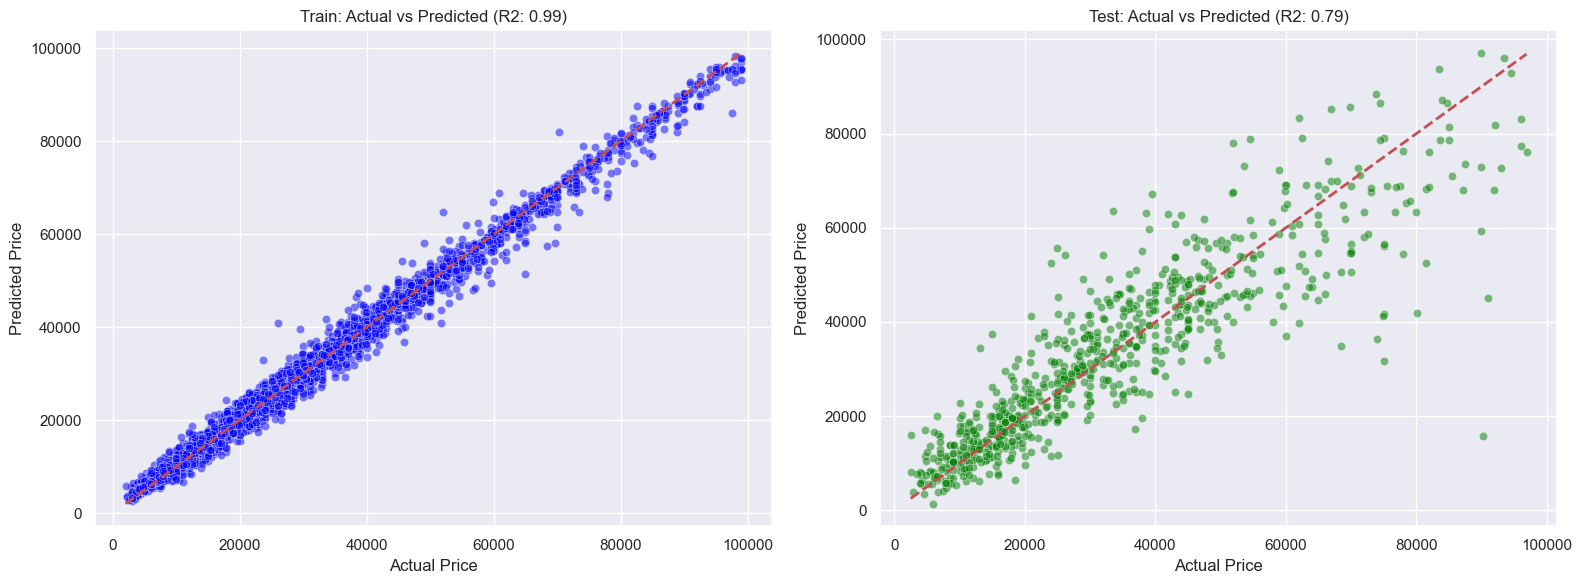

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# Plot for Training Data
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=train_preds, alpha=0.5, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title(f'Train: Actual vs Predicted (R2: {r2_score(y_train, train_preds):.2f})')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot for Test Data
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=test_preds, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Test: Actual vs Predicted (R2: {r2_score(y_test, test_preds):.2f})')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()

Saving the weights

In [41]:
import joblib

# Save the entire pipeline to a file
model_filename = 'car_price_xgb.joblib'
folder = 'Results/'
full_path = os.path.join(folder, model_filename)    
joblib.dump(xgb_pipeline, full_path)

print(f"Model and weights successfully saved to {full_path}")

Model and weights successfully saved to Results/car_price_xgb.joblib


Now generate a prediction using the saved weighta

In [44]:
import pandas as pd

# 1. Create a dictionary with your car's details
# Make sure the keys match your original CSV column names exactly!
new_car_data = {
    'brand': ['Ford'],
    'model': ['F-150'],
    'age': [5],
    'horse_power': [290],
    'cylinder_number': [6],
    'milage': [15000],
    'fuel_type': ['Gasoline'],
    'engine_capacity': [3.5],
    'transmission': ['Automatic'],
    'accident': ['None reported'],
    'clean_title': ['Yes']
}

# 2. Convert to DataFrame
new_car_df = pd.DataFrame(new_car_data)

# 3. Use the pipeline to predict
prediction = xgb_pipeline.predict(new_car_df)

print(f"The predicted price for this car is: ${prediction[0]:,.2f}")

The predicted price for this car is: $36,879.99
